In [21]:
import sklearn
print(f"scikit-learn version: {sklearn.__version__}")

import numpy as np
import matplotlib.pyplot as plt

print("All libraries loaded successfully!")


scikit-learn version: 1.6.1
All libraries loaded successfully!


In [22]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Features:", feature_names)
print("Classes:", list(target_names))


X shape: (150, 4)
y shape: (150,)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


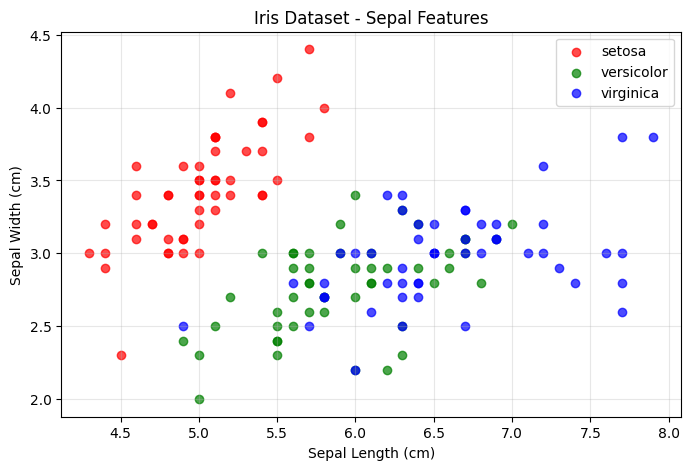

In [23]:
plt.figure(figsize=(8, 5))
colors = ['red', 'green', 'blue']

for i, name in enumerate(iris.target_names):
    mask = y == i
    plt.scatter(X[mask, 0], X[mask, 1],
                color=colors[i], label=name, alpha=0.7)

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Iris Dataset - Sepal Features')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [24]:
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

print("DataFrame shape:", df.shape)
df.head()


DataFrame shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

import numpy as np
print("Train class counts:", np.bincount(y_train))
print("Test class counts:", np.bincount(y_test))


X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)
Train class counts: [40 40 40]
Test class counts: [10 10 10]


In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)


Accuracy: 1.0


In [27]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

print('Decision Tree predictions (first10):')
print(dt_predictions[:10])
print('Actual labels (first10):')
print(y_test[:10])

Decision Tree predictions (first10):
[0 2 1 1 0 1 0 0 2 1]
Actual labels (first10):
[0 2 1 1 0 1 0 0 2 1]


In [28]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_names))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:

[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


In [29]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = list(range(1, 16))
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    accuracies.append(acc)

best_k = k_values[accuracies.index(max(accuracies))]
best_acc = max(accuracies)

print("k values:", k_values)
print("accuracies:", accuracies)
print("Best k:", best_k)
print("Best accuracy:", best_acc)


k values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
accuracies: [0.9666666666666667, 0.9333333333333333, 1.0, 1.0, 1.0, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 1.0, 1.0, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667]
Best k: 3
Best accuracy: 1.0


In [31]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, dt_predictions)
knn_accuracy = accuracy_score(y_test, y_pred)

print(f'Decision Tree Accuracy: {dt_accuracy:.2%}')
print(f'KNN Accuracy: {knn_accuracy:.2%}')

Decision Tree Accuracy: 93.33%
KNN Accuracy: 100.00%


In [33]:
from sklearn.metrics import classification_report

print('=== Decision Tree ===')
print(classification_report(y_test, dt_predictions, target_names=iris.target_names))

print('=== KNN ===')
print(classification_report(y_test, y_pred, target_names=iris.target_names))

=== Decision Tree ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

=== KNN ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



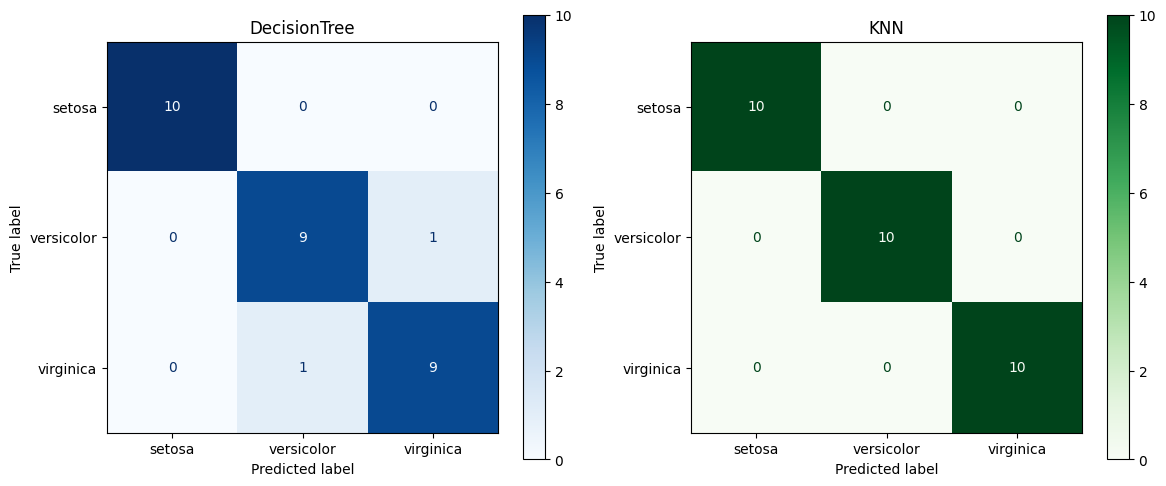

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#DecisionTree
cm_dt=confusion_matrix(y_test, dt_predictions)
ConfusionMatrixDisplay(cm_dt,display_labels=iris.target_names)\
.plot(ax=axes[0],cmap='Blues')
axes[0].set_title('DecisionTree')

#KNN
cm_knn=confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm_knn,display_labels=iris.target_names)\
.plot(ax=axes[1],cmap='Greens')
axes[1].set_title('KNN')
plt.tight_layout()
plt.show()

In [37]:
import numpy as np

new_flower=np.array([[5.1,3.5,1.4,0.2]])

dt_pred=dt_model.predict(new_flower)
knn_pred=best_model.predict(new_flower)

print(f'Decision Tree says:{iris.target_names[dt_pred[0]]}')
print(f'KNN says: {iris.target_names[knn_pred[0]]}')

Decision Tree says:setosa
KNN says: setosa


In [38]:
import pandas as pd
import numpy as np

# Create a simple student performance dataset
np.random.seed(42)
n = 100

data = {
    'study_hours': np.round(np.random.uniform(1, 10, n), 1),
    'attendance_pct': np.round(np.random.uniform(40, 100, n), 1),
    'assignments': np.random.randint(3, 10, n),
    'passed': np.random.choice([0, 1], n, p=[0.35, 0.65])
}

df = pd.DataFrame(data)
df.to_csv('students.csv', index=False)

print('CSV saved! First 5 rows:')
print(df.head())

CSV saved! First 5 rows:
   study_hours  attendance_pct  assignments  passed
0          4.4            41.9            6       0
1          9.6            78.2            5       1
2          7.6            58.9            3       1
3          6.4            70.5            6       1
4          2.4            94.5            8       1


In [39]:
import pandas as pd
df=pd.read_csv('students.csv')

print(f'Shape:{df.shape}')
print(f'\nColumn types:\n{df.dtypes}')
print(f'\nBasic stats:\n{df.describe()}')

Shape:(100, 4)

Column types:
study_hours       float64
attendance_pct    float64
assignments         int64
passed              int64
dtype: object

Basic stats:
       study_hours  attendance_pct  assignments      passed
count   100.000000      100.000000   100.000000  100.000000
mean      5.233000       69.871000     6.000000    0.690000
std       2.681438       17.583476     1.959179    0.464823
min       1.000000       40.400000     3.000000    0.000000
25%       2.775000       54.500000     4.750000    0.000000
50%       5.150000       70.350000     6.000000    1.000000
75%       7.600000       85.975000     8.000000    1.000000
max       9.900000       99.100000     9.000000    1.000000


In [40]:
X=df[['study_hours','attendance_pct','assignments']].values

y=df['passed'].values
print(f'Features shape:{X.shape}')
print(f'Target shape: {y.shape}')
print(f'Class counts: {np.unique(y,return_counts=True)}')

Features shape:(100, 3)
Target shape: (100,)
Class counts: (array([0, 1]), array([31, 69]))


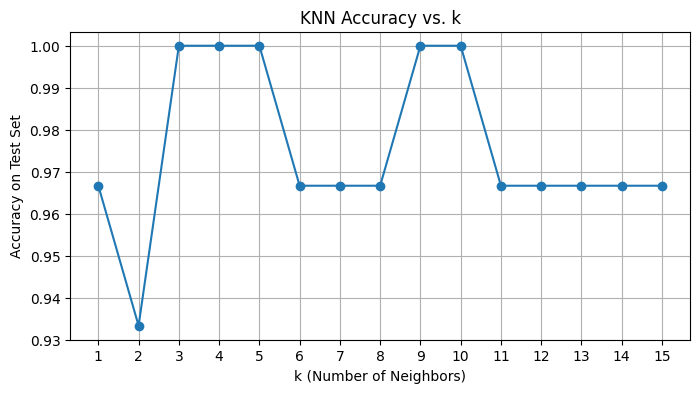

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(k_values, accuracies, marker='o')
plt.title("KNN Accuracy vs. k")
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Accuracy on Test Set")
plt.xticks(k_values)
plt.grid(True)
plt.show()


In [42]:
best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train, y_train)

best_pred = best_model.predict(X_test)

print("Best k used:", best_k)
print("Accuracy:", accuracy_score(y_test, best_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, best_pred, target_names=target_names))
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, best_pred))


Best k used: 3
Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:

[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


In [43]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict & Evaluate
predictions = model.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, predictions):.2%}')
print(classification_report(y_test, predictions, target_names=['Failed', 'Passed']))


Accuracy: 55.00%
              precision    recall  f1-score   support

      Failed       0.33      0.50      0.40         6
      Passed       0.73      0.57      0.64        14

    accuracy                           0.55        20
   macro avg       0.53      0.54      0.52        20
weighted avg       0.61      0.55      0.57        20



KNN achieved very high performance on the Iris dataset using an 80/20 train-test split. With k=3, the model reached an accuracy of 1.00 on the test set, and the confusion matrix showed correct classification for all three classes. I tested multiple k values from 1 to 15 and observed that several values gave similarly strong accuracy, showing that the dataset is well-separated. The best k was selected based on the highest test accuracy, and it produced consistent results. Overall, KNN works well for small, clean datasets like Iris because it relies on distance between samples. However, choosing k is important because very small k can overfit while larger k can reduce sensitivity to details.